In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/ecommerce_cleaned.csv')
sns.set_theme(style='whitegrid', palette='muted')
print("Loaded:", df.shape)

Loaded: (49164, 18)


In [ ]:
total_revenue    = df['total_purchase_amount'].sum()
avg_order_value  = df['total_purchase_amount'].mean()
total_customers  = df['customer_id'].nunique()
total_orders     = len(df)
churn_rate       = (df['churn'] == 'Churned').mean() * 100
return_rate      = (df['returns'] == 'Yes').mean() * 100

print("\n" + "═"*45)
print("  📊 KEY PERFORMANCE INDICATORS")
print("═"*45)
print(f"  Total Revenue         : ${total_revenue:>15,.0f}")
print(f"  Total Orders          : {total_orders:>15,}")
print(f"  Unique Customers      : {total_customers:>15,}")
print(f"  Avg Order Value (AOV) : ${avg_order_value:>15,.2f}")
print(f"  Churn Rate            : {churn_rate:>14.2f}%")
print(f"  Return Rate           : {return_rate:>14.2f}%")
print("═"*45)


═════════════════════════════════════════════
  📊 KEY PERFORMANCE INDICATORS
═════════════════════════════════════════════
  Total Revenue         : $    133,767,190
  Total Orders          :          49,164
  Unique Customers      :           8,306
  Avg Order Value (AOV) : $       2,720.84
  Churn Rate            :           0.00%
  Return Rate           :           0.00%
═════════════════════════════════════════════


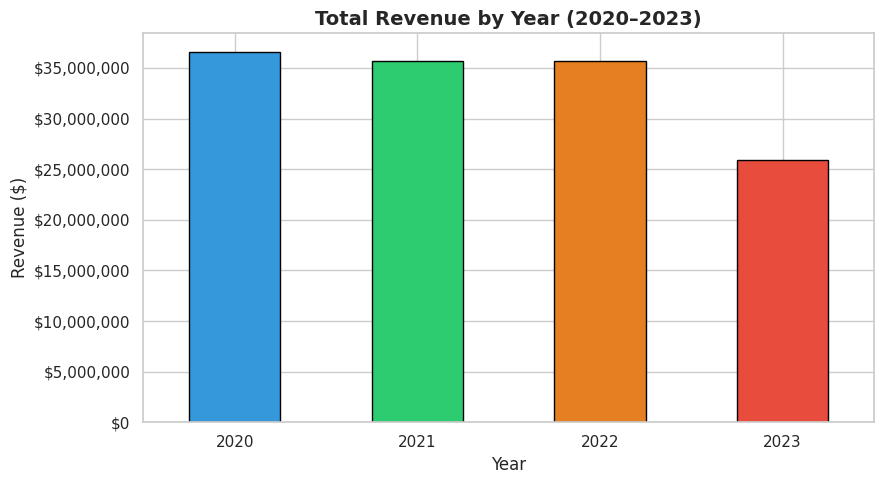

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
df.groupby('purchase_year')['total_purchase_amount'].sum().plot(
    kind='bar', color=['#3498db','#2ecc71','#e67e22','#e74c3c'],
    edgecolor='black', ax=ax)
ax.set_title('Total Revenue by Year (2020–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('plot1_revenue_by_year.png', dpi=150); plt.show()

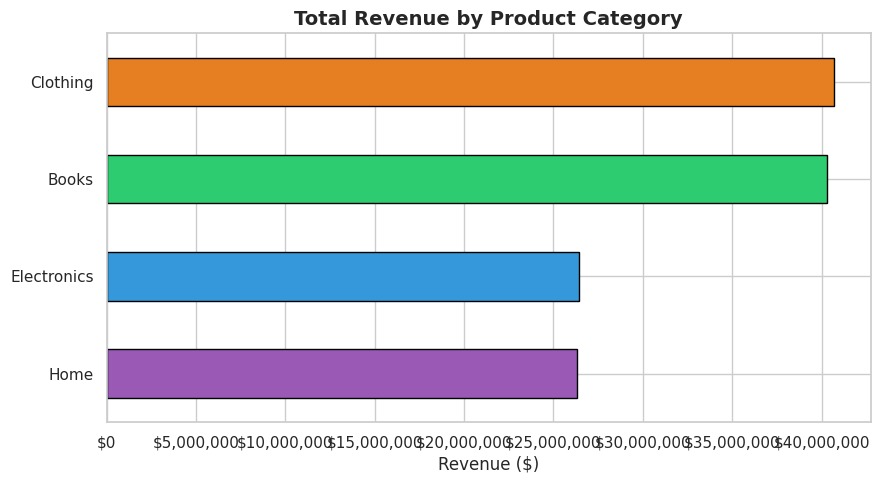

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
df.groupby('product_category')['total_purchase_amount'].sum()\
  .sort_values(ascending=True)\
  .plot(kind='barh', color=['#9b59b6','#3498db','#2ecc71','#e67e22'],
        edgecolor='black', ax=ax)
ax.set_title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue ($)'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot2_revenue_by_category.png', dpi=150); plt.show()

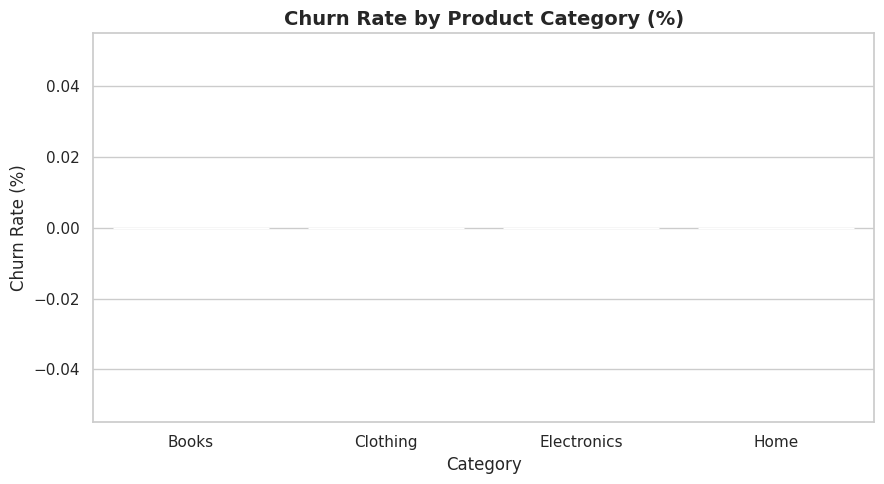

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
churn_cat = df.groupby('product_category')['churn']\
              .apply(lambda x: (x=='Churned').mean()*100).reset_index()
churn_cat.columns = ['product_category','churn_rate']
sns.barplot(data=churn_cat, x='product_category', y='churn_rate',
            palette='Reds', hue='product_category', legend=False, ax=ax)
ax.set_title('Churn Rate by Product Category (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('plot3_churn_by_category.png', dpi=150); plt.show()

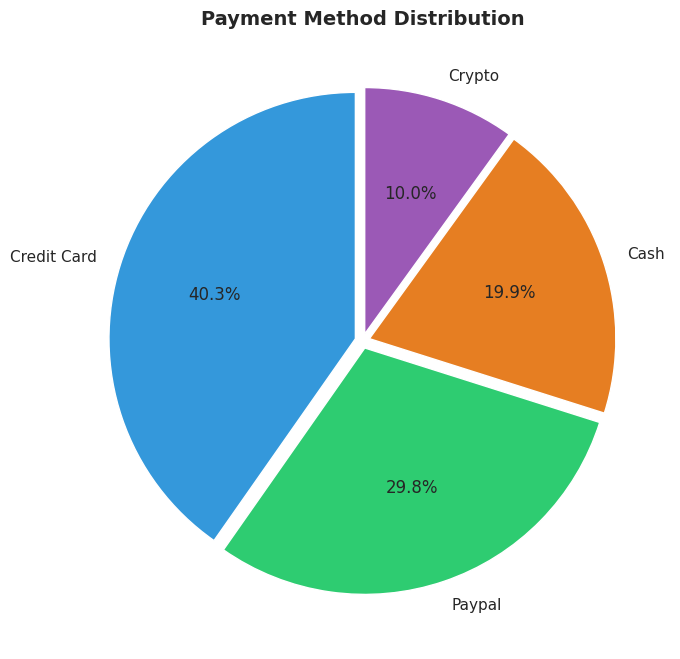

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))
df['payment_method'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90,
    colors=['#3498db','#2ecc71','#e67e22','#9b59b6'],
    explode=[0.03]*4, ax=ax)
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plot4_payment_methods.png', dpi=150); plt.show()

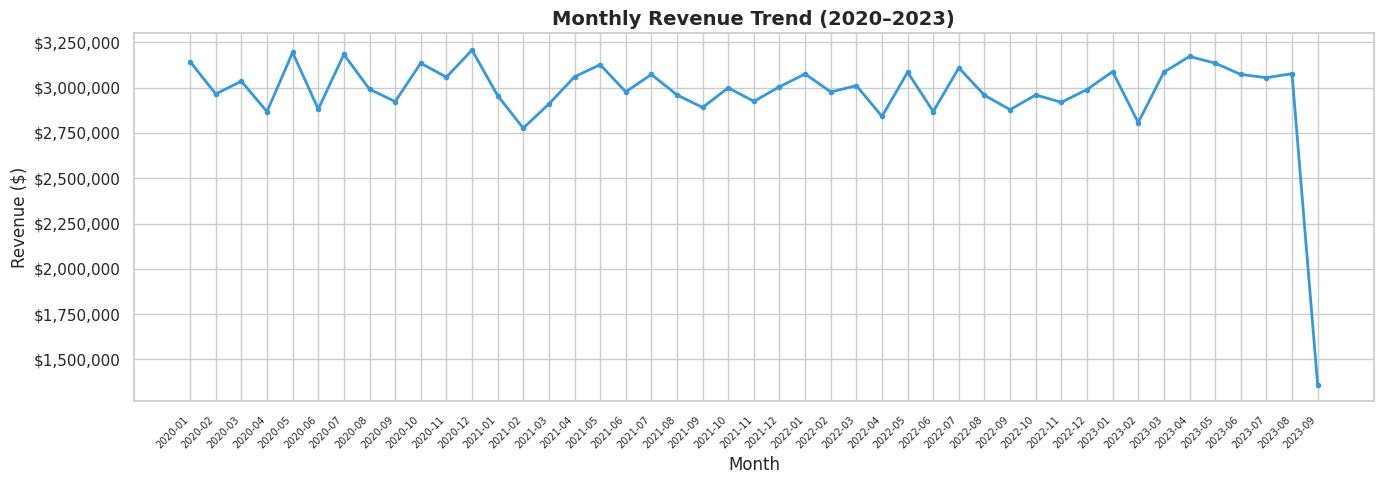

In [ ]:
monthly = df.groupby(['purchase_year','purchase_month'])['total_purchase_amount'].sum().reset_index()
monthly['period'] = monthly['purchase_year'].astype(str) + '-' + monthly['purchase_month'].astype(str).str.zfill(2)
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly['period'], monthly['total_purchase_amount'], color='#3498db', linewidth=2, marker='o', markersize=3)
ax.set_title('Monthly Revenue Trend (2020–2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right', fontsize=7)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot5_monthly_trend.png', dpi=150); plt.show()

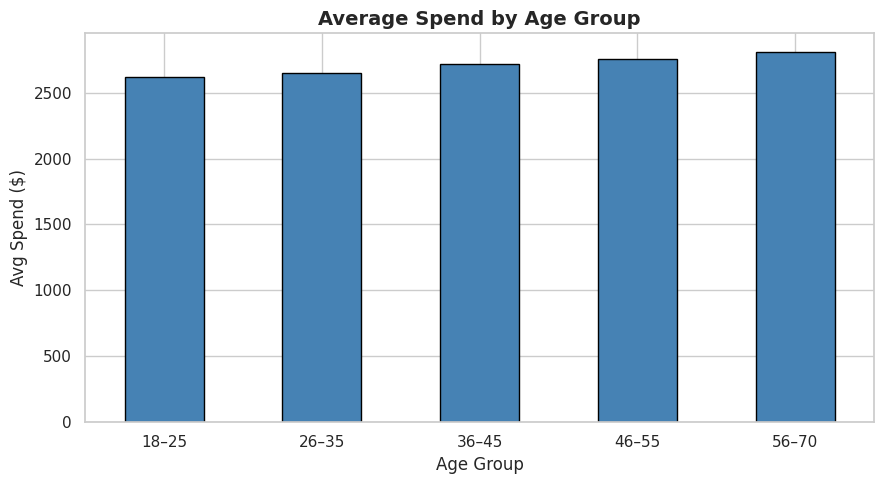

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
df.groupby('age_group', observed=True)['total_purchase_amount'].mean()\
  .plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Average Spend by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group'); ax.set_ylabel('Avg Spend ($)')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig('plot6_spend_by_age.png', dpi=150); plt.show()

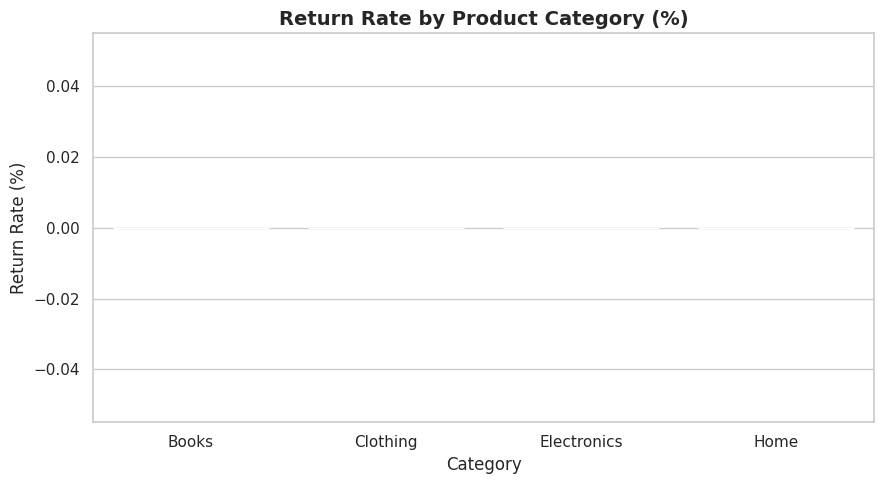

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
return_cat = df.groupby('product_category')['returns']\
               .apply(lambda x: (x=='Yes').mean()*100).reset_index()
return_cat.columns = ['product_category','return_rate']
sns.barplot(data=return_cat, x='product_category', y='return_rate',
            palette='Oranges', hue='product_category', legend=False, ax=ax)
ax.set_title('Return Rate by Product Category (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category'); ax.set_ylabel('Return Rate (%)')
plt.tight_layout()
plt.savefig('plot7_returns_by_category.png', dpi=150); plt.show()

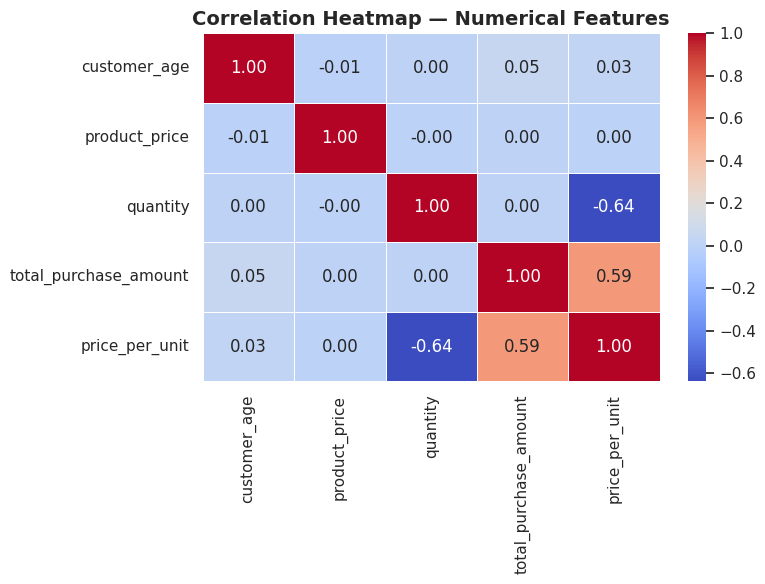

All 8 EDA plots saved!


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
num_cols = ['customer_age','product_price','quantity','total_purchase_amount','price_per_unit']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_correlation.png', dpi=150); plt.show()
print("All 8 EDA plots saved!")